Market stats 20251231-1Y, non nones count: 120032, needs 120032


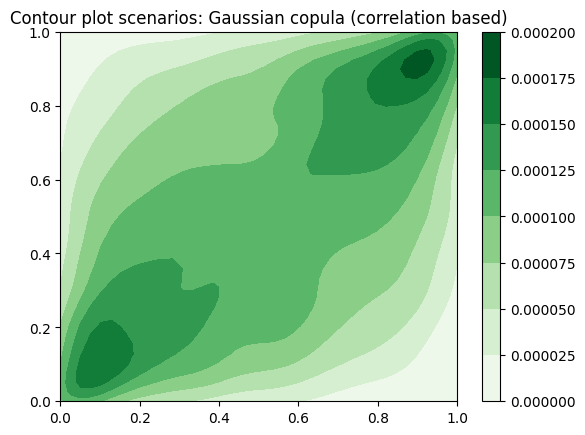

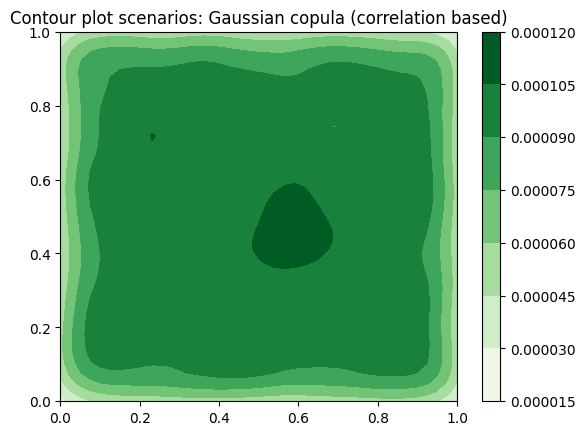

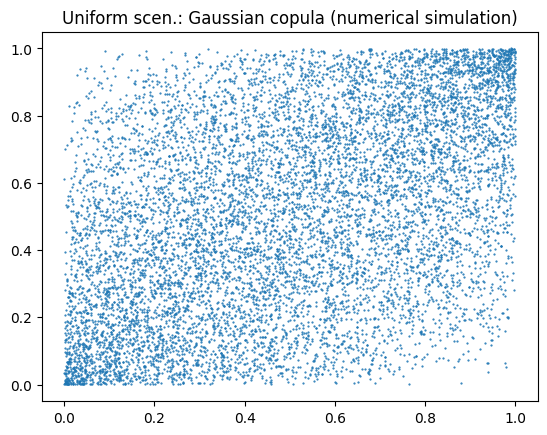

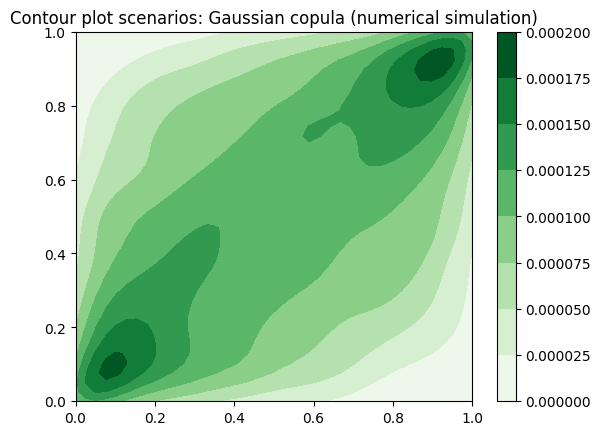

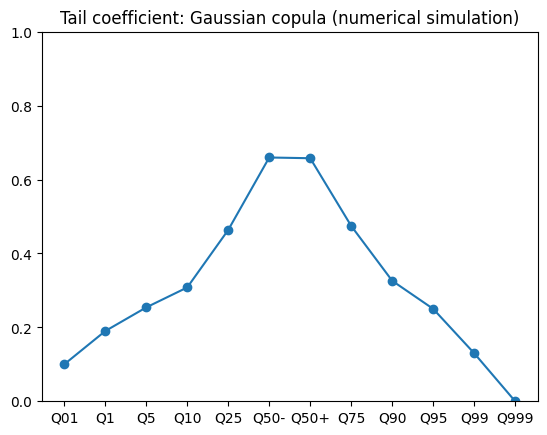

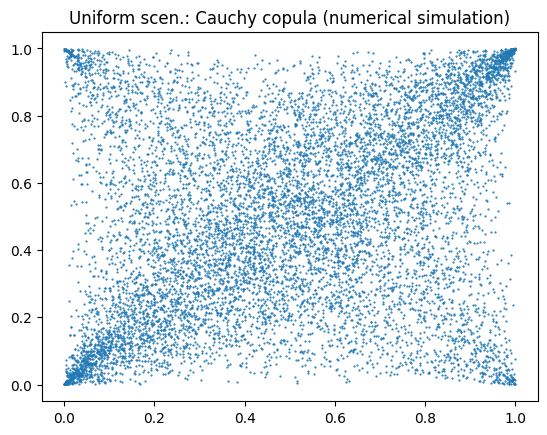

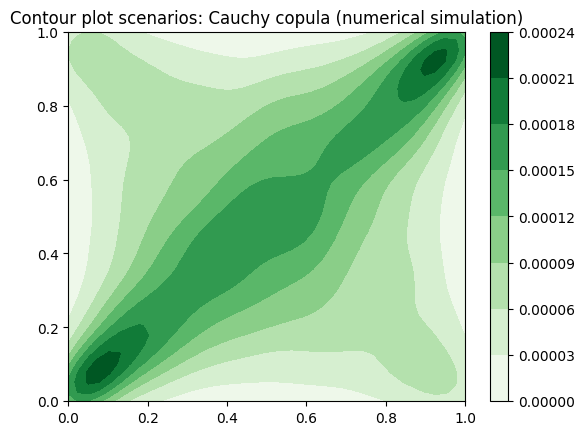

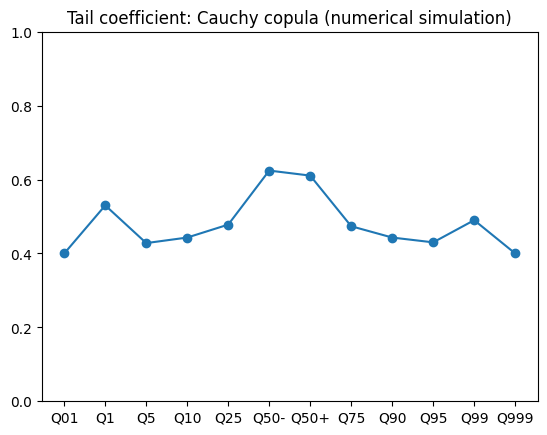

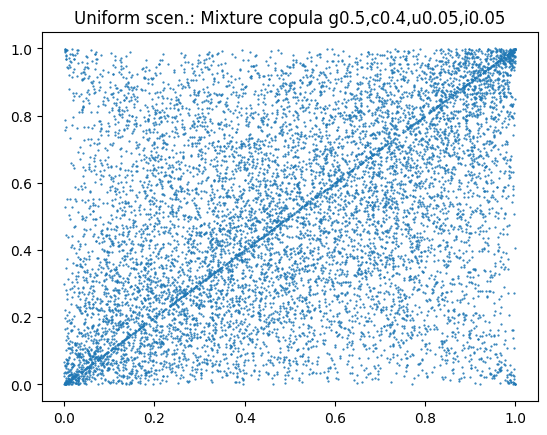

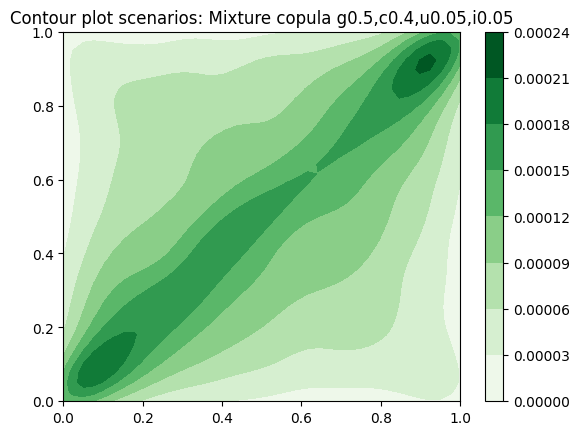

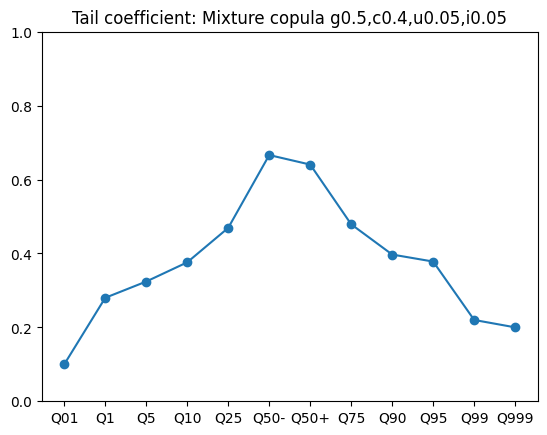

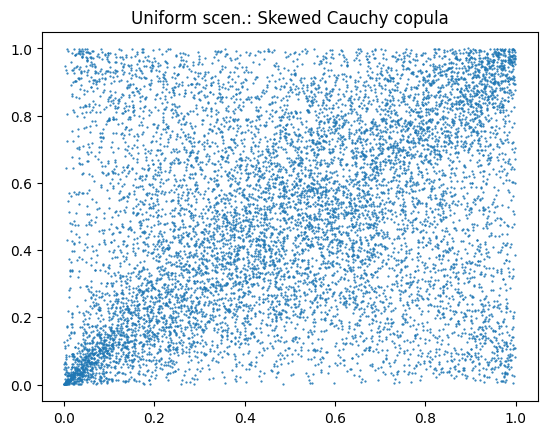

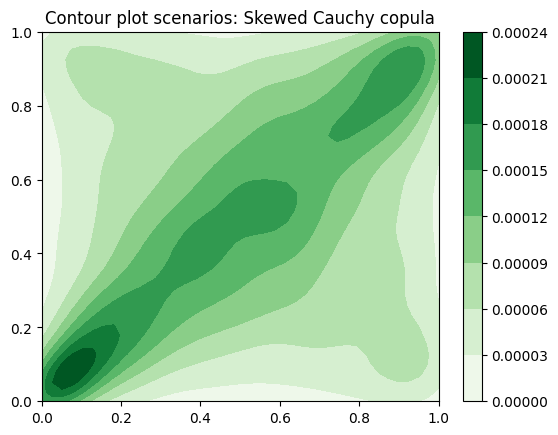

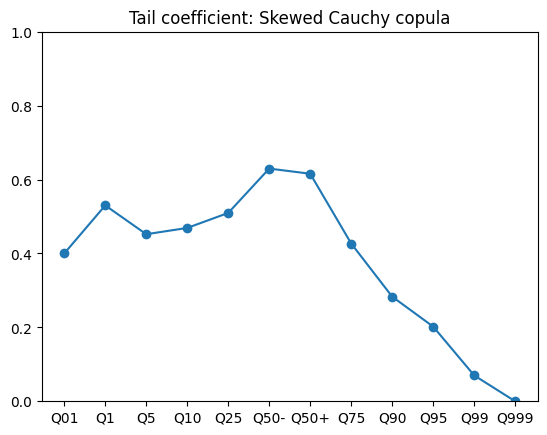

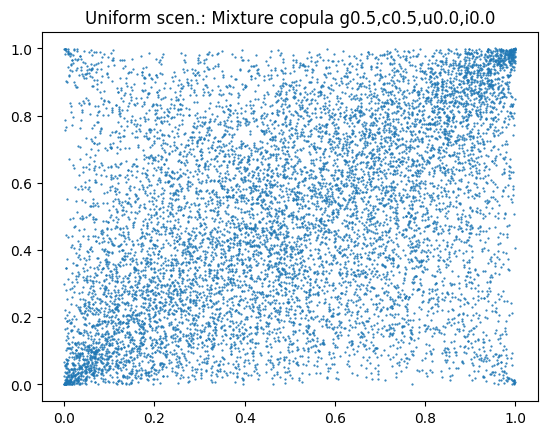

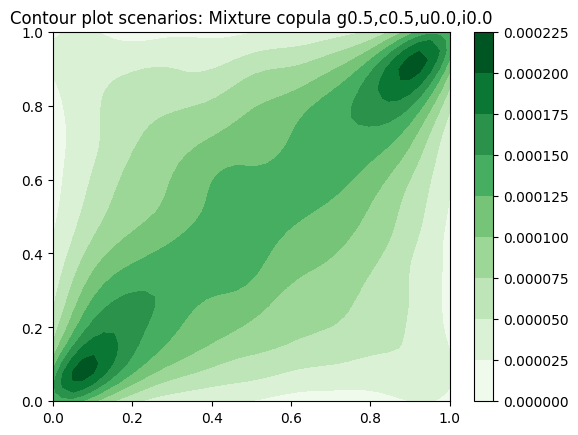

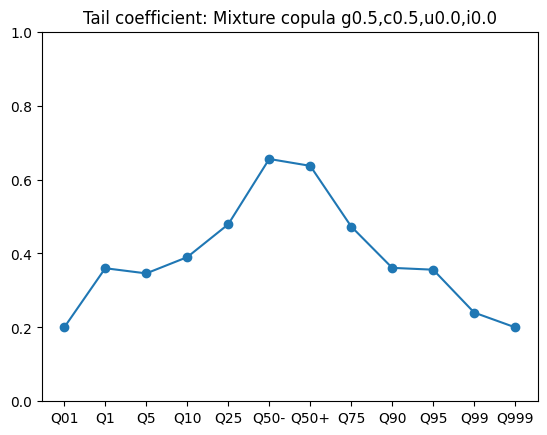

In [8]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

relpath = os.path.dirname(os.path.abspath(''))
ptf_name = 'SP500_LongAll'
output_path_part = 'C:\\Temp'
cob_date_str='20251231'
seed=0
num_scen = 10000

ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
market.load_history()
returns = market.get_logreturns(cob_date_str=cob_date_str, sub_period_years=1)


copula = js.GaussCopulaCorr(returns, [1.0]*len(ptf_names), seed=seed)
copula.get_sims(num_scen)
copula.plot_contour(1, 2)

copula = js.GaussCopulaCorr(returns, [1.0]*len(ptf_names), seed=seed)
copula.get_sims(num_scen,override_corr=0.0)
copula.plot_contour(1, 2)

copula = js.GaussCopulaNum(returns, [1.0]*len(ptf_names), seed=seed)
copula.get_sims(num_scen)
copula.plot_sims(1, 2)
copula.plot_contour(1, 2)
copula.plot_tailcoef(1, 2)

copula = js.CauchyCopulaNum(returns, [1.0]*len(ptf_names), seed=seed )
copula.get_sims(num_scen)
copula.plot_sims(1, 2)
copula.plot_contour(1, 2)
copula.plot_tailcoef(1, 2)

copula = js.MixCopulaNum(returns, [1.0]*len(ptf_names), seed=seed, weights=[0.5, 0.4, 0.05, 0.05])
copula.get_sims(num_scen)
copula.plot_sims(1, 2)
copula.plot_contour(1, 2)
copula.plot_tailcoef(1, 2)

weights = [0.95]*484
copula = js.SkewCopulaNum(returns, [1.0]*len(ptf_names), seed=seed, weights=weights)
copula.get_sims(num_scen)
copula.plot_sims(1, 2)
copula.plot_contour(1, 2)
copula.plot_tailcoef(1, 2)

copula = js.MixCopulaNum(returns, [1.0]*len(ptf_names), seed=seed, weights=[0.5, 0.5, 0.0, 0.0])
copula.get_sims(num_scen)
copula.plot_sims(1, 2)
copula.plot_contour(1, 2)
copula.plot_tailcoef(1, 2)





Market stats 20251231-1Y, non nones count: 120032, needs 120032
GaussCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
CauchyCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
MixCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
MixCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
MixCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
Market stats 20251201-1Y, non nones count: 120516, needs 120516
GaussCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
CauchyCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
MixCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
MixCopulaNum-VarSim
=> min:0.0

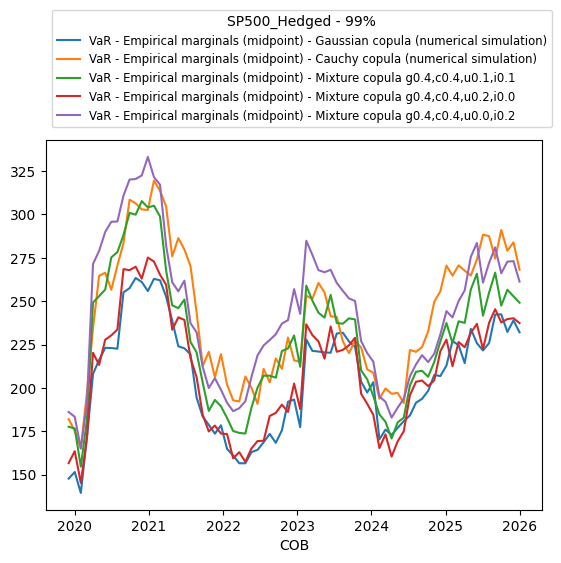

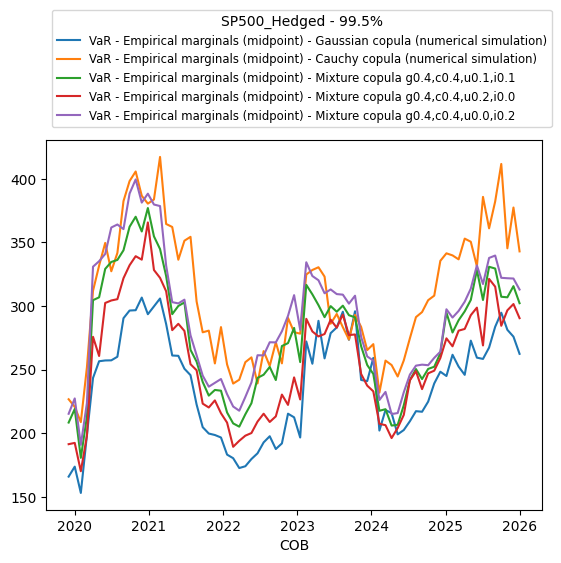

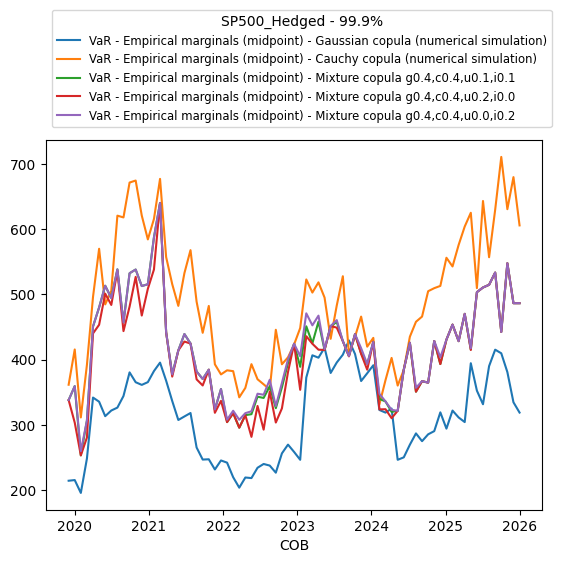

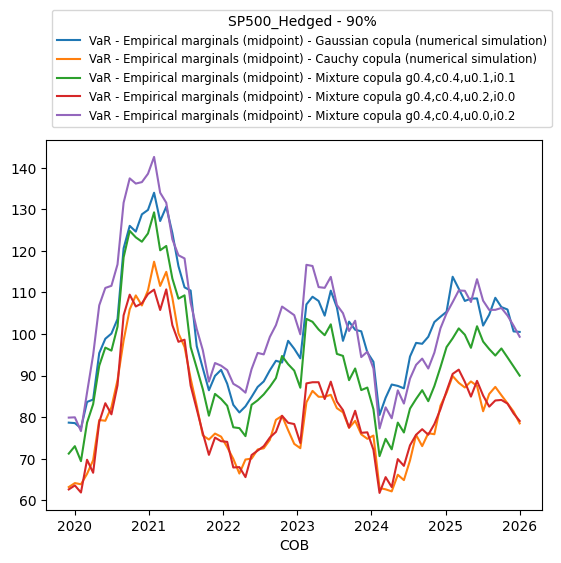

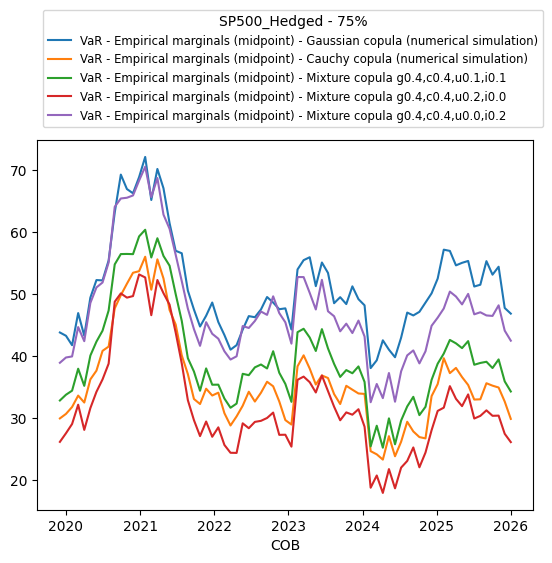

In [8]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

relpath = os.path.dirname(os.path.abspath(''))
ptf_name = 'SP500_Hedged' # 'SP500_Hedged', 'SP500_LongAll', 'SP500_ShortAll'
direct = -1.0 if ptf_name=="SP500_ShortAll" else 1.0
output_path_part = 'C:\\Temp'
#meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('HistSimulation', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1]), ('SkewCopulaNum', 'VarSim', [0.95]*484)]
meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.2, 0.0]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.0, 0.2])]
cob_date_str='20251231'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
market.load_history()

res = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res2 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res3 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res4 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res5 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)
    col_res, date_res, date_res2, date_res3, date_res4, date_res5 = ['COB'], [new_cob_date], [new_cob_date], [new_cob_date], [new_cob_date], [new_cob_date]
    
    for meth in meth_list:
        print(f'{meth[0]}-{meth[1]}')
        copula = getattr(js, meth[0])

        joint_sim = copula(returns, [direct]*len(ptf_names), seed=0) if meth[0] not in ['MixCopulaNum', 'SkewCopulaNum'] else copula(returns, [direct]*len(ptf_names), seed=0, weights=meth[2])

        var_meth = getattr(v, meth[1])
        port_sim = var_meth(returns, market.spot, joint_sim, np.array(ptf_wghts), method='midpoint')
        port_sim.calculate_pnls(10000)
        port_var = -round(port_sim.get_quantile(0.01)/port_sim.get_port_value()*100,2)
        port_var2 = -round(port_sim.get_quantile(0.005)/port_sim.get_port_value()*100,2)
        port_var3 = -round(port_sim.get_quantile(0.001)/port_sim.get_port_value()*100,2)
        port_var4 = -round(port_sim.get_quantile(0.1)/port_sim.get_port_value()*100,2)
        port_var5 = -round(port_sim.get_quantile(0.25)/port_sim.get_port_value()*100,2)
        date_res.append(port_var); date_res2.append(port_var2); date_res3.append(port_var3); date_res4.append(port_var4); date_res5.append(port_var5); col_res.append(port_sim.name)

    res.columns, res2.columns, res3.columns, res4.columns, res5.columns = col_res, col_res, col_res, col_res, col_res
    res_temp = pd.DataFrame(data=[date_res], columns=col_res)
    res_temp2 = pd.DataFrame(data=[date_res2], columns=col_res)
    res_temp3 = pd.DataFrame(data=[date_res3], columns=col_res)
    res_temp4 = pd.DataFrame(data=[date_res4], columns=col_res)
    res_temp5 = pd.DataFrame(data=[date_res5], columns=col_res)
    res = pd.concat([res, res_temp], ignore_index=True)
    res2 = pd.concat([res2, res_temp2], ignore_index=True)
    res3 = pd.concat([res3, res_temp3], ignore_index=True)
    res4 = pd.concat([res4, res_temp4], ignore_index=True)
    res5 = pd.concat([res5, res_temp5], ignore_index=True)

res.set_index('COB', inplace=True); 
res.to_csv(f'{output_path_part}\\{ptf_name}-var_990.csv')
res.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_990.png', bbox_inches="tight")
plt.show()

res2.set_index('COB', inplace=True); 
res2.to_csv(f'{output_path_part}\\{ptf_name}-var_995.csv')
res2.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.5%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_995.png', bbox_inches="tight")
plt.show()

res3.set_index('COB', inplace=True); 
res3.to_csv(f'{output_path_part}\\{ptf_name}-var_999.csv')
res3.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.9%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_999.png', bbox_inches="tight")
plt.show()

res4.set_index('COB', inplace=True); 
res4.to_csv(f'{output_path_part}\\{ptf_name}-var_900.csv')
res4.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 90%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_900.png', bbox_inches="tight")
plt.show()

res5.set_index('COB', inplace=True);
res5.to_csv(f'{output_path_part}\\{ptf_name}-var_750.csv')
res5.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 75%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_750.png', bbox_inches="tight")
plt.show()

#TODO:
# 1) result stats i.e. multi quantile etc. 
# 2) logging /storing with decorator 
# 3) mixture copula & copula 1 & copula 0
# 4) different marginals

Market stats 20251231-1Y, non nones count: 98208, needs 98208
GaussCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
CauchyCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
HistSimulation-VarSim
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 3928320, needs 3928320
MixCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
SkewCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
Market stats 20251201-1Y, non nones count: 98604, needs 98604
GaussCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
CauchyCopulaNum-VarSim
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 3960000, needs 3960000
HistSimulation-VarSim
=> min:0.004016064257028112, max:0.9999
Simulation stats, non nones count: 3944160, needs 3944160
M

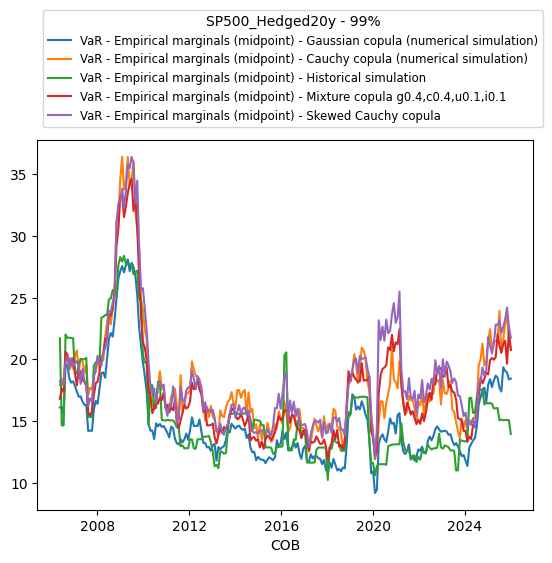

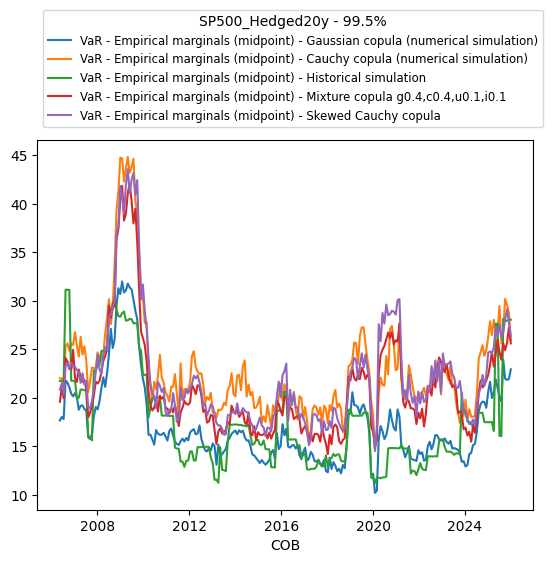

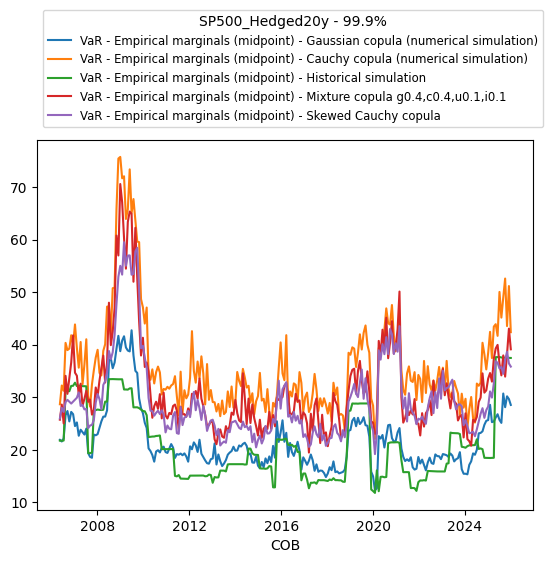

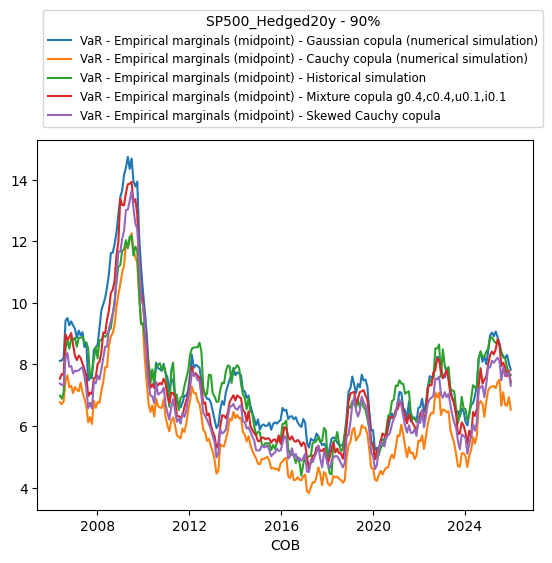

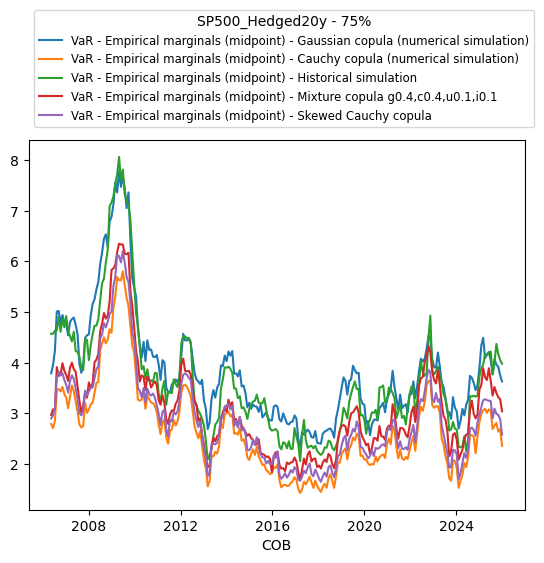

In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

relpath = os.path.dirname(os.path.abspath(''))
ptf_name = 'SP500_LongAll' # 'SP500_Hedged', 'SP500_LongAll'
output_path_part = 'C:\\Temp'
meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('HistSimulation', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1]), ('SkewCopulaNum', 'VarSim', [0.95]*396)]
#meth_list = [('GaussCopulaNum', 'VarSim'), ('CauchyCopulaNum', 'VarSim'), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.1, 0.1]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.2, 0.0]), ('MixCopulaNum', 'VarSim', [0.4, 0.4, 0.0, 0.2])]
cob_date_str='20251231'
figpath = 'C:\\dev\\MLCopula\\document\\figures\\full'

ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=20, interval='1d', cache_path=output_path_part)
market.load_history()

res = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res2 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res3 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res4 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
res5 = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
for i in range(240):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)
    col_res, date_res, date_res2, date_res3, date_res4, date_res5 = ['COB'], [new_cob_date], [new_cob_date], [new_cob_date], [new_cob_date], [new_cob_date]
    
    for meth in meth_list:
        print(f'{meth[0]}-{meth[1]}')
        copula = getattr(js, meth[0])

        joint_sim = copula(returns, [-1.0]*len(ptf_names), seed=0) if meth[0] not in ['MixCopulaNum', 'SkewCopulaNum'] else copula(returns, [-1.0]*len(ptf_names), seed=0, weights=meth[2])

        var_meth = getattr(v, meth[1])
        port_sim = var_meth(returns, market.spot, joint_sim, np.array(ptf_wghts), method='midpoint')
        port_sim.calculate_pnls(10000)
        port_var = -round(port_sim.get_quantile(0.01)/port_sim.get_port_value()*100,2)
        port_var2 = -round(port_sim.get_quantile(0.005)/port_sim.get_port_value()*100,2)
        port_var3 = -round(port_sim.get_quantile(0.001)/port_sim.get_port_value()*100,2)
        port_var4 = -round(port_sim.get_quantile(0.1)/port_sim.get_port_value()*100,2)
        port_var5 = -round(port_sim.get_quantile(0.25)/port_sim.get_port_value()*100,2)
        date_res.append(port_var); date_res2.append(port_var2); date_res3.append(port_var3); date_res4.append(port_var4); date_res5.append(port_var5); col_res.append(port_sim.name)

    res.columns, res2.columns, res3.columns, res4.columns, res5.columns = col_res, col_res, col_res, col_res, col_res
    res_temp = pd.DataFrame(data=[date_res], columns=col_res)
    res_temp2 = pd.DataFrame(data=[date_res2], columns=col_res)
    res_temp3 = pd.DataFrame(data=[date_res3], columns=col_res)
    res_temp4 = pd.DataFrame(data=[date_res4], columns=col_res)
    res_temp5 = pd.DataFrame(data=[date_res5], columns=col_res)
    res = pd.concat([res, res_temp], ignore_index=True)
    res2 = pd.concat([res2, res_temp2], ignore_index=True)
    res3 = pd.concat([res3, res_temp3], ignore_index=True)
    res4 = pd.concat([res4, res_temp4], ignore_index=True)
    res5 = pd.concat([res5, res_temp5], ignore_index=True)

res.set_index('COB', inplace=True); 
res.to_csv(f'{output_path_part}\\{ptf_name}-var_990.csv')
res.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_990.png', bbox_inches="tight")
plt.show()

res2.set_index('COB', inplace=True); 
res2.to_csv(f'{output_path_part}\\{ptf_name}-var_995.csv')
res2.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.5%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_995.png', bbox_inches="tight")
plt.show()

res3.set_index('COB', inplace=True); 
res3.to_csv(f'{output_path_part}\\{ptf_name}-var_999.csv')
res3.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 99.9%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_999.png', bbox_inches="tight")
plt.show()

res4.set_index('COB', inplace=True); 
res4.to_csv(f'{output_path_part}\\{ptf_name}-var_900.csv')
res4.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 90%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_900.png', bbox_inches="tight")
plt.show()

res5.set_index('COB', inplace=True);
res5.to_csv(f'{output_path_part}\\{ptf_name}-var_750.csv')
res5.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{ptf_name} - 75%')
plt.savefig(f'{figpath}\\Var_{ptf_name}_750.png', bbox_inches="tight")
plt.show()

#TODO:
# 1) result stats i.e. multi quantile etc. 
# 2) logging /storing with decorator 
# 3) mixture copula & copula 1 & copula 0
# 4) different marginals